In [36]:
# Cheminformatics (Colab-compatible RDKit build)
!pip install rdkit

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw
from rdkit.Chem import rdFingerprintGenerator

from sklearn.model_selection import train_test_split
from sklearn import metrics

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

sns.set(style="whitegrid")

In [38]:
DATA_PATH = "/content/sample_data/processed_kinase_with_fingerprints.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100169, 4)


,canonical_smiles,pchembl_value,active,fingerprint
0,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.397940,0,[0 1 1 ... 0 0 0]
1,CC[C@H](C)[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H](...,4.823909,0,[0 1 0 ... 0 0 0]
2,CC[C@H](C)[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H](...,5.744727,0,[0 1 0 ... 0 0 0]
3,CC[C@H](NC(=O)[C@H](Cc1ccc(OP(=O)(O)O)cc1)NC(C...,4.823909,0,[0 1 1 ... 0 0 0]
4,CC(=O)N[C@@H](Cc1ccc(C(F)(F)P(=O)(O)O)cc1)C(=O...,5.769551,0,[0 1 1 ... 0 0 0]


In [39]:
df = df[["canonical_smiles", "pchembl_value", "fingerprint"]].dropna()

df.rename(columns={
    "canonical_smiles": "smiles",
    "pchembl_value": "pIC50"
}, inplace=True)

df.head()

,smiles,pIC50,fingerprint
0,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.397940,[0 1 1 ... 0 0 0]
1,CC[C@H](C)[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H](...,4.823909,[0 1 0 ... 0 0 0]
2,CC[C@H](C)[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H](...,5.744727,[0 1 0 ... 0 0 0]
3,CC[C@H](NC(=O)[C@H](Cc1ccc(OP(=O)(O)O)cc1)NC(C...,4.823909,[0 1 1 ... 0 0 0]
4,CC(=O)N[C@@H](Cc1ccc(C(F)(F)P(=O)(O)O)cc1)C(=O...,5.769551,[0 1 1 ... 0 0 0]


In [40]:
def fix_fp(x):
    if isinstance(x, str):
        return np.fromstring(x.replace("[","").replace("]",""), sep=" ", dtype=int)
    return np.array(x, dtype=int)

df["fingerprint"] = df["fingerprint"].apply(fix_fp)

X = np.stack(df["fingerprint"].values)


/tmp/ipykernel_1143/3617127089.py:3: DeprecationWarning: string or file could not be read to its end due to unmatched data; this will raise a ValueError in the future.
  return np.fromstring(x.replace("[","").replace("]",""), sep=" ", dtype=int)


KeyboardInterrupt: 

In [41]:
X = np.stack(df["fingerprint"].values)
y = df["pIC50"].values

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Train:", x_train.shape)
print("Test :", x_test.shape)

Train: (70118, 3)
Test : (30051, 3)


In [42]:
model = Sequential()
model.add(Dense(64, activation="relu", input_shape=(X.shape[1],)))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="linear"))

model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mse", "mae"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
4383/4383 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 2.5183 - mae: 1.1929 - mse: 2.5183 - val_loss: 1.8438 - val_mae: 1.0919 - val_mse: 1.8438
Epoch 2/50
4383/4383 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 1.8176 - mae: 1.0922 - mse: 1.8176 - val_loss: 1.8077 - val_mae: 1.0908 - val_mse: 1.8077
Epoch 3/50
4383/4383 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 1.8165 - mae: 1.0921 - mse: 1.8165 - val_loss: 1.8142 - val_mae: 1.0894 - val_mse: 1.8142
Epoch 4/50
4383/4383 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 1.8149 - mae: 1.0915 - mse: 1.8149 - val_loss: 1.8386 - val_mae: 1.0920 - val_mse: 1.8386
Epoch 5/50
4383/4383 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 1.8154 - mae: 1.0916 - mse: 1.8154 - val_loss: 1.8501 - val_mae: 1.1081 - val_mse: 1.8501
Epoch 6/50
4383/4383 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 1.8141 - mae: 1.0916 - mse: 1.8141 - val_loss: 1.8224 - val_mae: 1.0978 - val_mse: 1.8224
Epoch 7/50
4383/4383 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 1.8138 - mae: 1.091

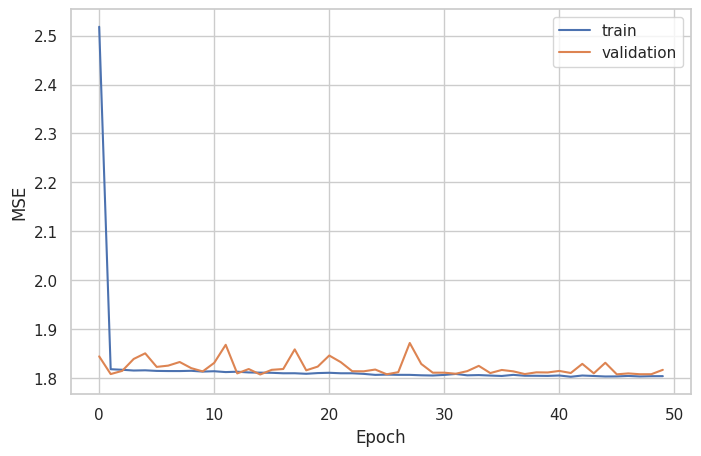

In [44]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()